{'image': '/home/czfy/AS_MAE_Data/nii_origin_instance_number_split_20241209/train/MR47041/T1.nii.gz'}
torch.Size([1, 873, 873, 56])


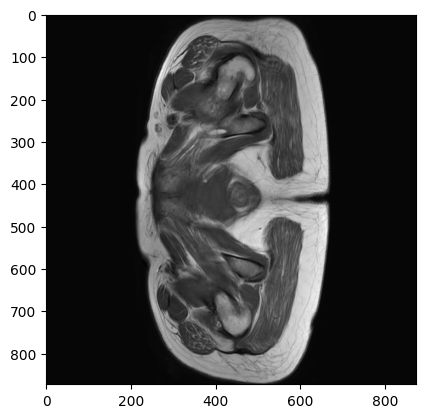

In [45]:
from pathlib import Path
from cv2 import imshow
from monai.config import PathLike
from monai.data import CacheDataset, DataLoader, Dataset, DistributedSampler, SmartCacheDataset, load_decathlon_datalist
from monai.transforms import (
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandSpatialCropSamplesd,
    ScaleIntensityRanged,
    SpatialPadd,
    ToTensord,
)
from utils.data_utils import get_custom_datalist
import matplotlib.pyplot as plt

datalist, val_files = get_custom_datalist(
    "/home/czfy/AS_MAE_Data/nii_origin_instance_number_split_20241209/", seq="T1"
)
transform_1 = Compose(
    [
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
    ]
)
print(datalist[0])
x_1 = transform_1(datalist[0])
print(x_1["image"].shape)
plt.imshow(x_1["image"][0][..., 0], cmap="gray")


torch.Size([1, 873, 873, 56])
[[-3.99444818e-01  1.72491129e-02 -9.67668593e-02  1.79826874e+02]
 [-1.72570050e-02 -3.99627566e-01  2.94108543e-10  1.36706451e+02]
 [-1.20845959e-02  5.21845766e-04  3.19853663e+00 -1.95873734e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
tensor([[ 3.9944e-01, -1.7249e-02, -9.6767e-02, -1.5345e+02],
        [ 1.7257e-02,  3.9963e-01,  2.9411e-10, -2.2682e+02],
        [ 1.2085e-02, -5.2185e-04,  3.1985e+00, -2.0596e+02],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)


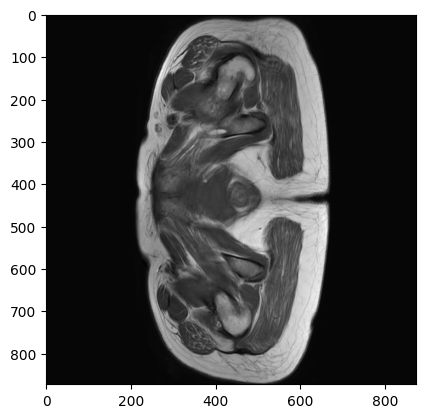

In [44]:
transform_2 = Orientationd(keys=["image"], axcodes="RAS")
x_2 = transform_2(x_1)
print(x_2["image"].shape)
plt.imshow(x_2["image"][0][...,0].flip(0,1), cmap="gray")
print(x_2["image"].meta["original_affine"])
print(x_2["image"].meta["affine"])

In [47]:
import torch
print(torch.tensor(x_2["image"].meta["original_affine"]).to(float) @ torch.tensor([0,0,0,1.]).to(float))
print(x_2["image"].meta["affine"].to(float)@torch.tensor([872,872,0,1]).to(float))

tensor([ 179.8269,  136.7065, -195.8737,    1.0000], dtype=torch.float64)
tensor([ 179.8269,  136.7065, -195.8737,    1.0000], dtype=torch.float64)


In [65]:
# test RandSpatialCropSamplesd
from monai.transforms import RandSpatialCropSamplesd,ToTensord
# x_2 = transform_1(datalist[:5])
sample =Compose([
     RandSpatialCropSamplesd(
    keys=["image"],
    roi_size=[96, 96, 96],
    num_samples=3,
    random_center=True,
),ToTensord(keys=["image"])])
# print(x_2.size())
sampled = sample(x_1)
print(sampled[0]["image"].shape)
# print(len(sampled))

torch.Size([1, 96, 96, 56])


In [60]:
sampled[0]["image"].shape


torch.Size([1, 96, 96, 10])